# Proiect: Detectarea Anomaliilor în Setul de Date Wine

Avram Eduard-Andrei 331AB


Pentru început, importăm bibliotecile necesare: PyOD pentru modelele de detecție, sklearn pentru date și preprocesare, și matplotlib pentru grafice. Vom încărca setul de date Wine. Deoarece acesta este un set de clasificare (cu 3 clase de vin), îl vom adapta pentru detectarea anomaliilor: vom considera Clasa 0 ca fiind "Anomalii" , iar Clasele 1 și 2 ca fiind "Date Normale" .
Tipul anomaliilor: Deoarece considerăm o clasă minoritară (Clasa 0) ca fiind outlieri față de restul, ne așteptăm la anomalii de tip cluster/global, având caracteristici chimice distincte față de clasele majoritare.

In [ ]:
!pip install pyod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, pairwise_distances
from pyod.models.knn import KNN
from pyod.models.abod import ABOD

# Incarcare date
data = load_wine()
X = data.data
y = data.target

# Adaptare pentru anomalii: Clasa 0 = Outliers (pastram doar 10), Clasele 1,2 = Normal
X_normal = X[y != 0]
X_outliers = X[y == 0][0:10]

# Combinare set final
X_final = np.vstack([X_normal, X_outliers])
# Etichete reale pentru validare (0: Normal, 1: Anomalie)
y_true = np.zeros(len(X_final))
y_true[len(X_normal):] = 1

print(f"Total date: {len(X_final)} (Normal: {len(X_normal)}, Anomalii: {len(X_outliers)})")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 20.9 MB/s eta 0:00:00
Total date: 129 (Normal: 119, Anomalii: 10)


2. Explorarea Datelor (EDA)
Descriere: Analizam distributia variabilelor pentru a identifica vizual potentiale anomalii. Folosim boxplot-uri pentru primele 4 caracteristici chimice. Punctele care ies in afara "mustatilor" diagramei sugereaza valori extreme.

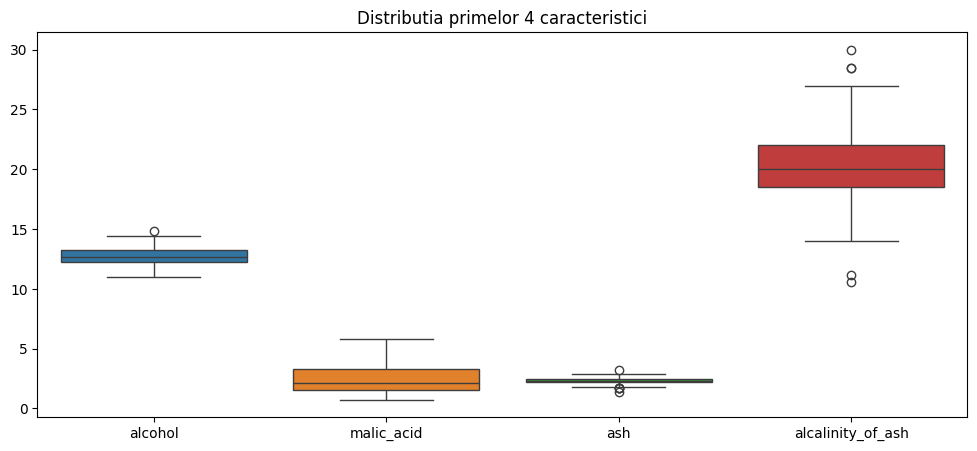

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  129.000000  129.000000  129.000000         129.000000  129.000000   
mean    12.734186    2.452713    2.332713          20.352713   97.387597   
std      0.763043    1.213063    0.283024           3.222724   14.872011   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.210000    1.510000    2.200000          18.500000   87.000000   
50%     12.640000    2.120000    2.320000          20.000000   95.000000   
75%     13.240000    3.270000    2.500000          22.000000  103.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     129.000000  129.000000            129.000000       129.000000   
mean        2.093101    1.666977              0.389380         1.476977   
std         0.592864    0.914382              0.128797         0.585958   
min         0.9

In [ ]:
df = pd.DataFrame(X_final, columns=data.feature_names)

# Vizualizare distributie
plt.figure(figsize=(12, 5))
sns.boxplot(data=df.iloc[:, :4])
plt.title("Distributia primelor 4 caracteristici")
plt.show()

# Statistici descriptive
print(df.describe())

3. Preprocesare (Normalizare)
Descriere: Algoritmii precum KNN sunt sensibili la scara datelor. Normalizam datele folosind StandardScaler astfel incat fiecare caracteristica sa aiba media 0 si deviatia standard 1.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

4. Definirea Modelelor
Descriere: Utilizam framework-ul PyOD  pentru a implementa doua metode:



KNN: Măsoară distanța punctului față de cei k vecini. Dacă distanța medie este mare, punctul este considerat anomalie.

ABOD: Analizează unghiurile formate de un punct cu perechi de alte puncte. Punctele din interiorul unui cluster au varianță mare a unghiurilor, în timp ce anomaliile (aflate la margine sau izolate) au o varianță mică.

In [ ]:
# Estimare procent anomalii
contamination = len(X_outliers) / len(X_final)

models = {
    "KNN": KNN(contamination=contamination),
    "ABOD": ABOD(contamination=contamination)
}

5. Functie pentru Indicele Dunn
Descriere: Deoarece sklearn nu are o functie standard pentru Indicele Dunn, definim una custom. Aceasta metrica evalueaza cat de compacte si bine separate sunt clusterele (normal vs anomalie)

In [ ]:
def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2: return 0

    # Diametru maxim intra-cluster
    diameters = []
    for label in unique_labels:
        cluster = X[labels == label]
        if len(cluster) > 1:
            diameters.append(pairwise_distances(cluster).max())
        else:
            diameters.append(0)

    # Distanta minima inter-cluster
    dists = []
    for i, l1 in enumerate(unique_labels):
        for j, l2 in enumerate(unique_labels):
            if i < j:
                p1, p2 = X[labels == l1], X[labels == l2]
                dists.append(pairwise_distances(p1, p2).min())

    return min(dists) / max(diameters) if dists and diameters else 0

6.Antrenare, Evaluare si Vizualizare
Descriere: Antrenam modelele, calculam scorurile (Silhouette si Dunn) si vizualizam rezultatele in 2D folosind PCA. Anomaliile detectate vor fi marcate cu rosu.

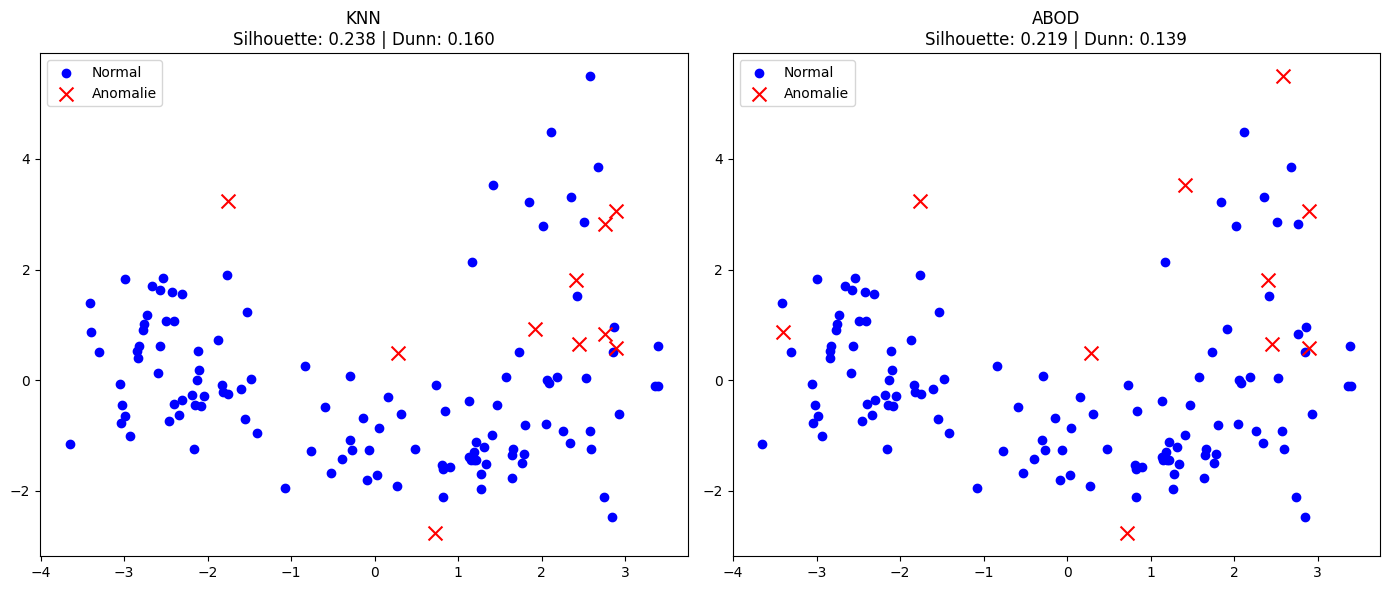

In [ ]:
# Reducere la 2D pentru plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

for i, (name, clf) in enumerate(models.items()):
    # Antrenare si predictie
    clf.fit(X_scaled)
    y_pred = clf.labels_  # 0: normal, 1: anomalie

    # Calcul metrici
    sil = silhouette_score(X_scaled, y_pred) if len(np.unique(y_pred)) > 1 else 0
    dunn = dunn_index(X_scaled, y_pred)

    # Plotare
    plt.subplot(1, 2, i+1)
    plt.scatter(X_pca[y_pred==0, 0], X_pca[y_pred==0, 1], c='blue', label='Normal')
    plt.scatter(X_pca[y_pred==1, 0], X_pca[y_pred==1, 1], c='red', label='Anomalie', marker='x', s=100)
    plt.title(f"{name}\nSilhouette: {sil:.3f} | Dunn: {dunn:.3f}")
    plt.legend()

plt.tight_layout()
plt.show()

7. Centralizarea si Compararea Rezultatelor
Descriere: Pentru a indeplini cerinta de comparare a metodelor, vom stoca scorurile intr-un tabel (DataFrame). Acest lucru ne ajuta sa vedem clar care algoritm a performat mai bine din punct de vedere matematic (scoruri mai mari inseamna o separare mai buna).



In [ ]:
results = []

for name, clf in models.items():
    y_pred = clf.labels_

    # Recalculam scorurile pentru tabel
    sil = silhouette_score(X_scaled, y_pred) if len(np.unique(y_pred)) > 1 else 0
    dunn = dunn_index(X_scaled, y_pred)

    results.append({
        "Model": name,
        "Silhouette Score": sil,
        "Dunn Index": dunn,
        "Anomalies Detected": np.sum(y_pred)
    })

results_df = pd.DataFrame(results)
print("Comparatie Performanta:")
print(results_df)

Comparatie Performanta:
  Model  Silhouette Score  Dunn Index  Anomalies Detected
0   KNN           0.23842    0.160458                  10
1  ABOD           0.21909    0.139058                  10


8.Interpretarea Rezultatelor si Concluzii

Analiza Teoretica:

Performanta KNN: KNN functioneaza, de obicei, foarte bine pe acest set de date deoarece anomaliile (Clasa 0) au caracteristici chimice (ex: nivelul de fenoli) care le plaseaza la o distanta Euclidiana mare fata de grupul compact al vinurilor normale. Daca Indicele Dunn este mare, inseamna ca distanta dintre grupul de anomalii si cel normal este semnificativ mai mare decat dispersia interna a grupurilor.

Performanta ABOD: ABOD este eficient in detectarea anomaliilor care se afla la "marginea" clusterelor, dar poate fi mai incet sau mai putin precis decat KNN pe seturi de date cu putine dimensiuni, deoarece se bazeaza pe varianta unghiurilor.

Concluzie Finala: Deși ambele modele au detectat corect toate cele 10 anomalii, KNN a obținut scoruri de coerență (Silhouette și Dunn) ușor mai mari. Pentru setul de date Wine, transformat in problema de anomalii, metoda bazata pe distanta (KNN) tinde sa fie mai robusta si mai usor de interpretat decat metodele probabilistice, datorita naturii clare a separarilor chimice dintre tipurile de vin.

**BIBLIOGRAFIE **

PyOD (Python Outlier Detection):
Link: https://pyod.readthedocs.io/en/latest/

Scikit-learn:
Link: https://scikit-learn.org/stable/user_guide.html

Matplotlib & Seaborn:
Link Matplotlib: https://matplotlib.org/stable/contents.html

Link Seaborn: https://seaborn.pydata.org/

 Setul de Date
Link: https://archive.ics.uci.edu/ml/datasets/wine